# 🎯 YOLO Object Detection Lab - Interactive Session

## 🚀 Objectifs
- Découvrir YOLO (You Only Look Once) pour la détection d'objets
- Interface interactive pour tester sur images/vidéos
- Détection en temps réel avec webcam
- Analyse des performances et métriques

---
*Session 05 - SupNum Nouakchott - Formation IA & Machine Learning*

In [ ]:
%pip install ultralytics

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import io
import base64
import os
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# Try to import ultralytics YOLO
try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
    print("✅ Ultralytics YOLO disponible")
except ImportError:
    YOLO_AVAILABLE = False
    print("⚠️ Ultralytics non installé. Installation requise: pip install ultralytics")

# Configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🚀 YOLO Object Detection Lab initialisé!")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\mohamed.beydia\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics YOLO disponible
🚀 YOLO Object Detection Lab initialisé!


## 📚 1. Introduction à YOLO

### 🤔 Qu'est-ce que YOLO ?
**YOLO (You Only Look Once)** est une architecture révolutionnaire pour la détection d'objets :

- **🏃‍♂️ Rapide** : Une seule passe dans le réseau
- **🎯 Précis** : Détection + classification simultanées  
- **🔄 Temps réel** : Parfait pour applications live
- **📦 Complet** : Bounding boxes + classes + confiance

### 🏆 Versions YOLO :
- **YOLOv3** : Première version populaire
- **YOLOv5** : Plus rapide et précise
- **YOLOv8** : État de l'art actuel (2023)
- **YOLOv11** : Dernière version (2024)

In [3]:
# Configuration globale
if YOLO_AVAILABLE:
    # Charger le modèle YOLOv8 pré-entraîné
    print("📥 Chargement du modèle YOLOv8...")
    model = YOLO('yolov8n.pt')  # nano version pour rapidité
    print("✅ Modèle YOLOv8 chargé!")
    
    # Classes COCO (80 objets)
    class_names = model.names
    print(f"🏷️ {len(class_names)} classes disponibles")
else:
    print("❌ Veuillez installer ultralytics: pip install ultralytics")
    model = None
    class_names = {}

📥 Chargement du modèle YOLOv8...
✅ Modèle YOLOv8 chargé!
🏷️ 80 classes disponibles


## 🏷️ 2. Classes d'Objets Détectables

### 📋 YOLO peut détecter 80 types d'objets différents :

🏷️ CLASSES D'OBJETS DÉTECTABLES PAR YOLO:

🚗 Véhicules:
   • car
   • motorcycle
   • bus
   • train
   • truck

👥 Personnes:
   • person

🐾 Animaux:
   • bird
   • cat
   • dog
   • horse
   • sheep
   • cow
   • elephant
   • bear
   • zebra
   • giraffe

🍎 Nourriture:
   • banana
   • apple
   • sandwich
   • orange
   • broccoli
   • carrot
   • hot dog
   • pizza
   • donut
   • cake

⚽ Sports:
   • sports ball
   • kite
   • baseball bat
   • baseball glove
   • skateboard
   • surfboard

🏠 Mobilier:
   • chair
   • couch
   • potted plant
   • bed
   • dining table
   • toilet
   • tv


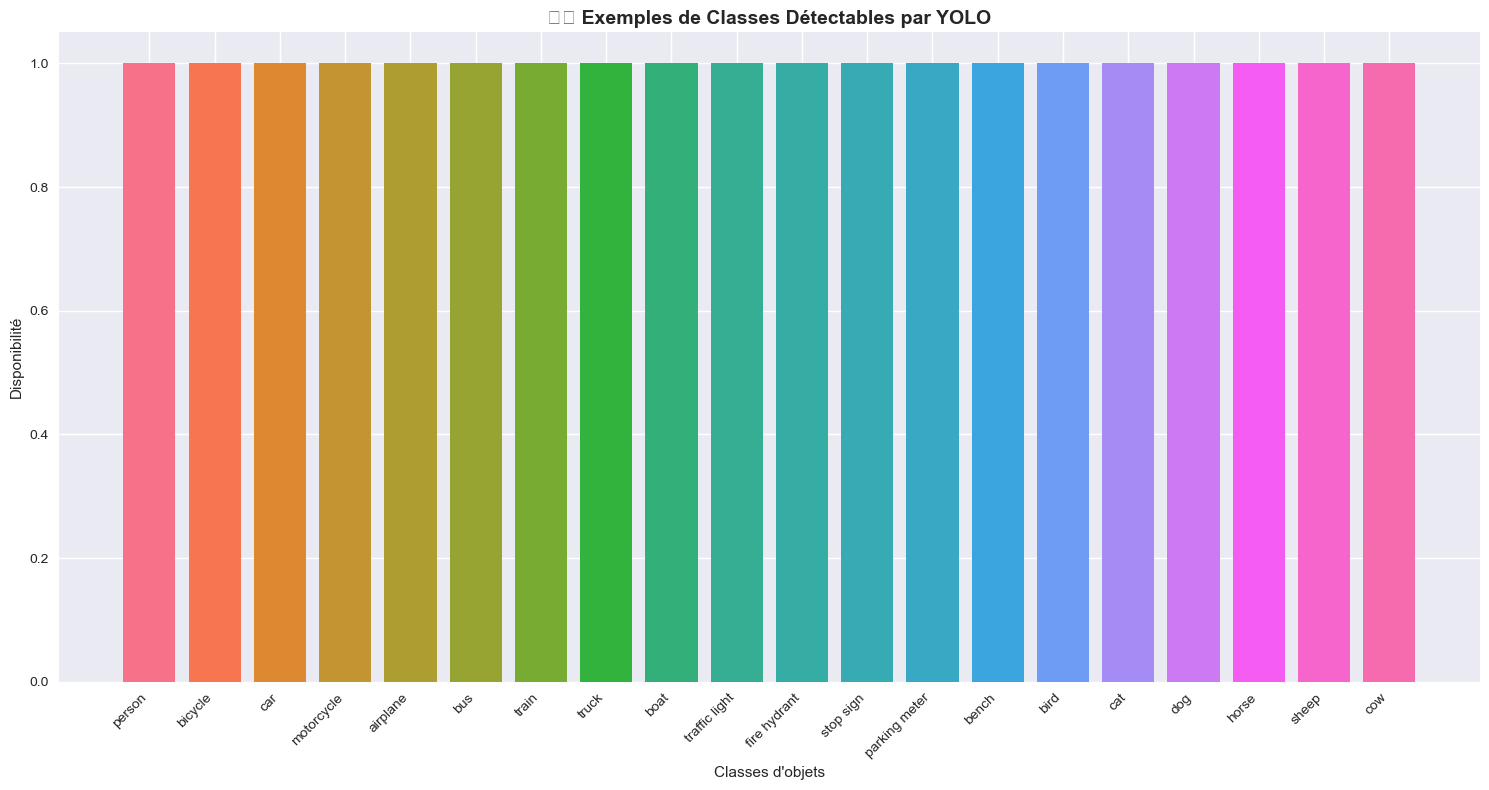

In [4]:
if YOLO_AVAILABLE and class_names:
    print("🏷️ CLASSES D'OBJETS DÉTECTABLES PAR YOLO:")
    print("=" * 50)
    
    # Organiser les classes par catégories
    categories = {
        "🚗 Véhicules": [2, 3, 5, 6, 7],  # car, motorcycle, bus, train, truck
        "👥 Personnes": [0],  # person
        "🐾 Animaux": [14, 15, 16, 17, 18, 19, 20, 21, 22, 23],  # bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe
        "🍎 Nourriture": [46, 47, 48, 49, 50, 51, 52, 53, 54, 55],  # banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake
        "⚽ Sports": [32, 33, 34, 35, 36, 37],  # sports ball, kite, baseball bat, baseball glove, skateboard, surfboard
        "🏠 Mobilier": [56, 57, 58, 59, 60, 61, 62]  # chair, couch, potted plant, bed, dining table, toilet, tv
    }
    
    for category, indices in categories.items():
        print(f"\n{category}:")
        for idx in indices:
            if idx in class_names:
                print(f"   • {class_names[idx]}")
    
    # Graphique des classes
    plt.figure(figsize=(15, 8))
    class_ids = list(class_names.keys())[:20]  # Première 20 classes
    class_labels = [class_names[i] for i in class_ids]
    
    bars = plt.bar(range(len(class_labels)), [1]*len(class_labels), 
                   color=sns.color_palette("husl", len(class_labels)))
    plt.title('🏷️ Exemples de Classes Détectables par YOLO', fontweight='bold', fontsize=14)
    plt.xlabel('Classes d\'objets')
    plt.ylabel('Disponibilité')
    plt.xticks(range(len(class_labels)), class_labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 🖼️ 3. Détection sur Images - Interface Interactive

In [5]:
def detect_objects_in_image(image_array, confidence_threshold=0.5):
    """Détecte les objets dans une image"""
    if not YOLO_AVAILABLE or model is None:
        return image_array, []
    
    try:
        # Prédiction YOLO
        results = model(image_array, conf=confidence_threshold)
        
        # Extraire les résultats
        detections = []
        annotated_image = image_array.copy()
        
        for result in results:
            boxes = result.boxes
            if boxes is not None:
                for box in boxes:
                    # Coordonnées
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    confidence = box.conf[0].cpu().numpy()
                    class_id = int(box.cls[0].cpu().numpy())
                    class_name = class_names[class_id]
                    
                    detections.append({
                        'class': class_name,
                        'confidence': confidence,
                        'bbox': (int(x1), int(y1), int(x2), int(y2))
                    })
                    
                    # Dessiner la bounding box
                    color = (0, 255, 0)  # Vert
                    cv2.rectangle(annotated_image, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
                    
                    # Label avec confiance
                    label = f"{class_name}: {confidence:.2f}"
                    label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0]
                    cv2.rectangle(annotated_image, (int(x1), int(y1) - label_size[1] - 10), 
                                (int(x1) + label_size[0], int(y1)), color, -1)
                    cv2.putText(annotated_image, label, (int(x1), int(y1) - 5), 
                              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        return annotated_image, detections
        
    except Exception as e:
        print(f"❌ Erreur détection: {e}")
        return image_array, []

# Interface d'upload d'images
upload_image = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='📸 Upload Image'
)

confidence_slider = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=1.0,
    step=0.1,
    description='🎯 Confiance:',
    style={'description_width': 'initial'}
)

detect_button = widgets.Button(
    description='🔍 Détecter Objets',
    button_style='primary'
)

output_detection = widgets.Output()

def detect_on_image(button):
    """Lance la détection sur l'image uploadée"""
    with output_detection:
        clear_output(wait=True)
        
        if not upload_image.value:
            print("❌ Veuillez uploader une image")
            return
        
        if not YOLO_AVAILABLE:
            print("❌ YOLO non disponible. Installez ultralytics")
            return
        
        try:
            # Charger l'image
            uploaded_file = list(upload_image.value.values())[0]
            image_bytes = io.BytesIO(uploaded_file['content'])
            image = Image.open(image_bytes)
            image_array = np.array(image)
            
            print("🔍 Détection en cours...")
            start_time = time.time()
            
            # Détection
            annotated_image, detections = detect_objects_in_image(
                image_array, confidence_slider.value
            )
            
            detection_time = time.time() - start_time
            
            # Affichage
            fig, axes = plt.subplots(1, 2, figsize=(16, 8))
            
            # Image originale
            axes[0].imshow(image_array)
            axes[0].set_title('📸 Image Originale', fontweight='bold')
            axes[0].axis('off')
            
            # Image avec détections
            axes[1].imshow(annotated_image)
            axes[1].set_title(f'🎯 Détections YOLO ({len(detections)} objets)', fontweight='bold')
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Résultats détaillés
            print(f"⏱️ Temps de détection: {detection_time:.3f}s")
            print(f"🎯 Objets détectés: {len(detections)}")
            print("\n📋 DÉTAILS DES DÉTECTIONS:")
            print("=" * 40)
            
            if detections:
                for i, det in enumerate(detections, 1):
                    print(f"{i}. {det['class']} - Confiance: {det['confidence']:.1%}")
                    x1, y1, x2, y2 = det['bbox']
                    print(f"   📍 Position: ({x1}, {y1}) → ({x2}, {y2})")
                
                # Graphique des détections
                classes_detected = [det['class'] for det in detections]
                confidences = [det['confidence'] for det in detections]
                
                plt.figure(figsize=(12, 6))
                bars = plt.bar(classes_detected, confidences, 
                              color=sns.color_palette("husl", len(classes_detected)))
                plt.title('📊 Confiance des Détections', fontweight='bold')
                plt.xlabel('Classes d\'objets')
                plt.ylabel('Niveau de confiance')
                plt.xticks(rotation=45)
                
                # Ajouter les valeurs sur les barres
                for bar, conf in zip(bars, confidences):
                    height = bar.get_height()
                    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                             f'{conf:.2f}', ha='center', va='bottom')
                
                plt.tight_layout()
                plt.show()
            else:
                print("❌ Aucun objet détecté")
                print("💡 Essayez de réduire le seuil de confiance")
                
        except Exception as e:
            print(f"❌ Erreur: {e}")

detect_button.on_click(detect_on_image)

print("🖼️ Détection d'Objets sur Images")
print("=" * 40)
print("📝 Instructions:")
print("1. Uploadez une image")
print("2. Ajustez le seuil de confiance")
print("3. Cliquez sur 'Détecter Objets'")

display(widgets.VBox([
    upload_image,
    confidence_slider,
    detect_button,
    output_detection
]))

🖼️ Détection d'Objets sur Images
📝 Instructions:
1. Uploadez une image
2. Ajustez le seuil de confiance
3. Cliquez sur 'Détecter Objets'


## 📹 4. Détection Vidéo en Temps Réel avec Webcam

In [6]:
class YOLOWebcam:
    def __init__(self):
        self.cap = None
        self.is_running = False
        self.confidence_threshold = 0.5
        
    def start_camera(self):
        """Démarre la caméra"""
        try:
            self.cap = cv2.VideoCapture(0)
            if not self.cap.isOpened():
                print("❌ Impossible d'accéder à la caméra")
                return False
            
            # Configuration optimale
            self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
            self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
            self.cap.set(cv2.CAP_PROP_FPS, 30)
            
            print("✅ Caméra initialisée")
            return True
        except Exception as e:
            print(f"❌ Erreur caméra: {e}")
            return False
    
    def stop_camera(self):
        """Arrête la caméra"""
        if self.cap:
            self.cap.release()
            self.cap = None
        self.is_running = False
        cv2.destroyAllWindows()
        print("📹 Caméra arrêtée")
    
    def run_detection(self, confidence_threshold=0.5):
        """Lance la détection en temps réel"""
        if not YOLO_AVAILABLE or model is None:
            print("❌ YOLO non disponible!")
            return
        
        if not self.start_camera():
            return
        
        self.is_running = True
        self.confidence_threshold = confidence_threshold
        
        print("🎥 Détection YOLO en cours...")
        print("💡 Appuyez sur 'q' pour quitter, 's' pour screenshot")
        
        fps_counter = 0
        fps_start_time = time.time()
        
        try:
            while self.is_running:
                ret, frame = self.cap.read()
                if not ret:
                    break
                
                # Détection YOLO
                results = model(frame, conf=self.confidence_threshold, verbose=False)
                
                # Annoter l'image
                annotated_frame = results[0].plot()
                
                # Calculer FPS
                fps_counter += 1
                if fps_counter % 30 == 0:
                    fps = 30 / (time.time() - fps_start_time)
                    fps_start_time = time.time()
                    
                # Afficher FPS
                cv2.putText(annotated_frame, f'FPS: {fps:.1f}', (10, 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                
                # Afficher le frame
                cv2.imshow('🎯 YOLO Object Detection - Live', annotated_frame)
                
                # Contrôles clavier
                key = cv2.waitKey(1) & 0xFF
                if key == ord('q'):
                    break
                elif key == ord('s'):
                    # Sauvegarder screenshot
                    timestamp = int(time.time())
                    filename = f'yolo_detection_{timestamp}.jpg'
                    cv2.imwrite(filename, annotated_frame)
                    print(f"📸 Screenshot sauvé: {filename}")
                    
        except KeyboardInterrupt:
            print("\n⏹️ Arrêt demandé")
        except Exception as e:
            print(f"❌ Erreur: {e}")
        finally:
            self.stop_camera()

# Instance webcam YOLO
yolo_webcam = YOLOWebcam()

# Interface de contrôle webcam
webcam_confidence = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=1.0,
    step=0.1,
    description='🎯 Confiance Webcam:',
    style={'description_width': 'initial'}
)

start_webcam_button = widgets.Button(
    description='🎥 Démarrer YOLO Webcam',
    button_style='success'
)

stop_webcam_button = widgets.Button(
    description='⏹️ Arrêter Webcam',
    button_style='danger'
)

webcam_output = widgets.Output()

def start_yolo_webcam(button):
    """Démarre la détection webcam YOLO"""
    with webcam_output:
        clear_output(wait=True)
        print("🎥 Démarrage de la détection YOLO en temps réel...")
        print("💡 Une fenêtre va s'ouvrir")
        print("⌨️ Contrôles: 'q' = quitter, 's' = screenshot")
        
    # Lancer dans un thread
    import threading
    thread = threading.Thread(
        target=yolo_webcam.run_detection, 
        args=(webcam_confidence.value,)
    )
    thread.daemon = True
    thread.start()

def stop_yolo_webcam(button):
    """Arrête la détection webcam"""
    with webcam_output:
        yolo_webcam.is_running = False
        yolo_webcam.stop_camera()
        print("⏹️ Détection YOLO arrêtée")

start_webcam_button.on_click(start_yolo_webcam)
stop_webcam_button.on_click(stop_yolo_webcam)

print("📹 Détection YOLO en Temps Réel")
print("=" * 40)
print("⚠️ Webcam requise")
print("🎯 Détection automatique de 80 types d'objets")

display(widgets.VBox([
    webcam_confidence,
    widgets.HBox([start_webcam_button, stop_webcam_button]),
    webcam_output
]))

📹 Détection YOLO en Temps Réel
⚠️ Webcam requise
🎯 Détection automatique de 80 types d'objets


## 📊 5. Analyse des Performances YOLO

In [ ]:
def benchmark_yolo():
    """Benchmark des performances YOLO"""
    if not YOLO_AVAILABLE or model is None:
        print("❌ YOLO non disponible")
        return
    
    print("⚡ BENCHMARK YOLO - ANALYSE DES PERFORMANCES")
    print("=" * 50)
    
    # Test sur différentes tailles d'images
    test_sizes = [(320, 320), (640, 640), (1280, 1280)]
    results = []
    
    for width, height in test_sizes:
        # Créer une image de test
        test_image = np.random.randint(0, 255, (height, width, 3), dtype=np.uint8)
        
        # Mesurer le temps d'inférence
        times = []
        for _ in range(5):  # 5 tests
            start_time = time.time()
            _ = model(test_image, verbose=False)
            inference_time = time.time() - start_time
            times.append(inference_time)
        
        avg_time = np.mean(times)
        fps = 1 / avg_time
        
        results.append({
            'size': f'{width}x{height}',
            'time': avg_time,
            'fps': fps
        })
        
        print(f"📐 {width}x{height}: {avg_time:.3f}s ({fps:.1f} FPS)")
    
    # Graphique des performances
    sizes = [r['size'] for r in results]
    fps_values = [r['fps'] for r in results]
    times = [r['time'] for r in results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # FPS par taille
    bars1 = ax1.bar(sizes, fps_values, color='lightgreen')
    ax1.set_title('🚀 FPS par Taille d\'Image', fontweight='bold')
    ax1.set_ylabel('Images par Seconde (FPS)')
    ax1.set_xlabel('Taille d\'Image')
    
    for bar, fps in zip(bars1, fps_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{fps:.1f}', ha='center', va='bottom')
    
    # Temps d'inférence
    bars2 = ax2.bar(sizes, times, color='lightcoral')
    ax2.set_title('⏱️ Temps d\'Inférence', fontweight='bold')
    ax2.set_ylabel('Temps (secondes)')
    ax2.set_xlabel('Taille d\'Image')
    
    for bar, time_val in zip(bars2, times):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{time_val:.3f}s', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Recommandations
    print("\n💡 RECOMMANDATIONS D'USAGE:")
    print("=" * 30)
    print("🏃‍♂️ Temps réel (>30 FPS): 320x320")
    print("⚖️ Équilibré (15-30 FPS): 640x640") 
    print("🎯 Haute précision (<15 FPS): 1280x1280")

# Bouton benchmark
benchmark_button = widgets.Button(
    description='⚡ Lancer Benchmark',
    button_style='info'
)

benchmark_output = widgets.Output()

def run_benchmark(button):
    """Lance le benchmark"""
    with benchmark_output:
        clear_output(wait=True)
        benchmark_yolo()

benchmark_button.on_click(run_benchmark)

display(benchmark_button, benchmark_output)

## 🎓 6. Guide Complet et Conseils d'Utilisation

### 📚 Ce que vous avez appris :

1. **🎯 YOLO Architecture** : Détection d'objets en une seule passe
2. **🖼️ Détection sur Images** : Upload et analyse automatique
3. **📹 Temps Réel** : Webcam avec détection live
4. **📊 Performance** : Analyse des vitesses selon la taille

### 💡 Conseils pour de meilleurs résultats :

#### 🖼️ Pour les Images :
- **Qualité** : Images nettes et bien éclairées
- **Résolution** : 640x640 pour un bon compromis
- **Objets** : Évitez les objets trop petits ou partiellement cachés

#### 📹 Pour la Webcam :
- **Éclairage** : Lumière naturelle ou éclairage uniforme
- **Distance** : Objets à distance moyenne (1-3 mètres)
- **Mouvement** : Évitez les mouvements trop rapides

#### ⚡ Pour les Performances :
- **YOLOv8n** : Plus rapide, moins précis
- **YOLOv8s/m** : Compromis vitesse/précision
- **YOLOv8l/x** : Plus lent, très précis

### 🔧 Applications Pratiques :

- **🚗 Surveillance Trafic** : Compter véhicules et piétons
- **🏪 Commerce** : Analyser comportement clients
- **🏠 Sécurité** : Détection d'intrusions
- **📱 Applications Mobiles** : Reconnaissance d'objets
- **🤖 Robotique** : Navigation et manipulation

### 📈 Prochaines Étapes :

1. **Custom Training** : Entraîner sur vos propres données
2. **Optimisation** : TensorRT, ONNX pour plus de vitesse
3. **Déploiement** : API REST, applications mobiles
4. **Tracking** : Suivi d'objets dans le temps

---
**🎉 Félicitations ! Vous maîtrisez maintenant YOLO pour la détection d'objets !**